# Linear Function Approximation

This notebook experiments with Q-learning using linear function approximation on CartPole and MountainCar. It compares the standard online update, which learns from each transition immediately, with replay-buffer Q-learning, which stores transitions and learns from sampled mini-batches.

Replay buffers and mini-batch updates are important techniques that will appear frequently in deep reinforcement learning. This experiment provides a simple setting for understanding how they change the learning process.

## Experiment Setup

Both agents use the same linear Q-function and are trained independently on the same environments. The only main difference is how they use experience: online Q-learning updates immediately from the latest transition, while the replay-buffer agent reuses stored transitions through mini-batch updates.

The learning curves are plotted against environment steps because episode lengths differ between CartPole and MountainCar.

## Comparing the Update Strategies

For each environment, the notebook compares training return, TD-error loss, parameter norms, and return against the number of gradient updates. Together, these plots show both learning performance and how online updates differ from replay-based mini-batch updates.

In [1]:
def _confidence_summary(runs, x_key, y_key, points=200):
    valid_runs = []
    for run in runs:
        x = np.asarray(run["history"][x_key], dtype=float)
        y = np.asarray(run["history"][y_key], dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)
        if np.count_nonzero(mask) >= 2:
            valid_runs.append((x[mask], y[mask]))

    if not valid_runs:
        return np.array([]), np.array([]), np.array([])

    x_min = max(x[0] for x, _ in valid_runs)
    x_max = min(x[-1] for x, _ in valid_runs)
    if x_max <= x_min:
        return np.array([]), np.array([]), np.array([])

    x_grid = np.linspace(x_min, x_max, points)
    values = np.vstack([np.interp(x_grid, x, y) for x, y in valid_runs])
    mean = values.mean(axis=0)
    confidence = 1.96 * values.std(axis=0, ddof=1) / np.sqrt(values.shape[0])
    return x_grid, mean, confidence


def plot_training_returns(results, env_id):
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent_name, runs in results[env_id].items():
        x, mean, confidence = _confidence_summary(
            runs, "environment_steps", "episode_returns"
        )
        ax.plot(x, mean, label=agent_name)
        ax.fill_between(x, mean - confidence, mean + confidence, alpha=0.2)
    ax.set_title(f"Training return: {env_id}")
    ax.set_xlabel("Environment steps")
    ax.set_ylabel("Episode return")
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_td_losses(results, env_id):
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent_name, runs in results[env_id].items():
        x, mean, confidence = _confidence_summary(runs, "environment_steps", "losses")
        ax.plot(x, mean, label=agent_name)
        ax.fill_between(x, mean - confidence, mean + confidence, alpha=0.2)
    ax.set_title(f"TD-error loss: {env_id}")
    ax.set_xlabel("Environment steps")
    ax.set_ylabel("Mean squared TD error")
    ax.set_yscale("symlog", linthresh=1e-3)
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_parameter_norms(results, env_id):
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent_name, runs in results[env_id].items():
        x, mean, confidence = _confidence_summary(
            runs, "environment_steps", "parameter_norms"
        )
        ax.plot(x, mean, label=agent_name)
        ax.fill_between(x, mean - confidence, mean + confidence, alpha=0.2)
    ax.set_title(f"Parameter norm: {env_id}")
    ax.set_xlabel("Environment steps")
    ax.set_ylabel("||w||₂ + ||b||₂")
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_return_by_updates(results, env_id):
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent_name, runs in results[env_id].items():
        x, mean, confidence = _confidence_summary(
            runs, "gradient_updates", "episode_returns"
        )
        ax.plot(x, mean, label=agent_name)
        ax.fill_between(x, mean - confidence, mean + confidence, alpha=0.2)
    ax.set_title(f"Return by gradient updates: {env_id}")
    ax.set_xlabel("Cumulative gradient updates")
    ax.set_ylabel("Episode return")
    ax.legend()
    fig.tight_layout()
    return fig, ax

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
AGENT_DIR = PROJECT_ROOT / "function-approximation" / "algorithms" / "linear-function-approximation"

if str(AGENT_DIR) not in sys.path:
    sys.path.insert(0, str(AGENT_DIR))

from linear_function_approximation import QLearningAgent
from lfa_replay_buffer import RBQLearningAgent

GLOBAL_SEED = 2026
np.random.seed(GLOBAL_SEED)
SEEDS = np.random.randint(0, 10000, size=10)
EPSILON = 0.1
LR = 0.01
GAMMA = 0.99
BUFFER_SIZE = 1000
BATCH_SIZE = 32

ENV_CONFIGS = {
    "CartPole-v1": {"max_episodes": 3000},
    "MountainCar-v0": {"max_episodes": 5000}
}

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
def build_agent(agent_name, env, seed):
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = env.action_space.n

    common_config = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "lr": LR,
        "gamma": GAMMA,
        "epsilon": EPSILON,
        "seed": seed,
    }

    if agent_name == "Online Q-learning":
        return QLearningAgent(**common_config)
    if agent_name == "Replay-buffer Q-learning":
        return RBQLearningAgent(
            **common_config,
            batch_size=BATCH_SIZE,
            buffer_size=BUFFER_SIZE,
        )
    raise ValueError(f"Unknown agent: {agent_name}")


def run_experiment(env_id, agent_name, seed, max_episodes):
    env = gym.make(env_id)
    agent = build_agent(agent_name, env, seed)
    history = agent.learn(env, max_episodes=max_episodes)
    env.close()
    return history


def run_all_experiments(env_configs=ENV_CONFIGS, seeds=SEEDS):
    results = {}
    for env_id, config in env_configs.items():
        results[env_id] = {}
        for agent_name in ["Online Q-learning", "Replay-buffer Q-learning"]:
            results[env_id][agent_name] = []
            for seed in seeds:
                history = run_experiment(
                    env_id=env_id,
                    agent_name=agent_name,
                    seed=seed,
                    max_episodes=config["max_episodes"],
                )
                results[env_id][agent_name].append({"seed": seed, "history": history})
    return results

## Run Experiments

The active comparison uses CartPole and MountainCar. Acrobot is outside the scope of this notebook and is not included in the default run.

In [6]:
ACTIVE_ENV_CONFIGS = {
    "CartPole-v1": ENV_CONFIGS["CartPole-v1"],
    "MountainCar-v0": ENV_CONFIGS["MountainCar-v0"],
}

results = run_all_experiments(env_configs=ACTIVE_ENV_CONFIGS, seeds=SEEDS)
results.keys()

dict_keys(['CartPole-v1', 'MountainCar-v0'])

## Visualize Results

The same four plots are produced for each environment. The mean line shows the average across seeds, while the shaded region shows a 95% confidence band. The plots should be read together: return measures task performance, TD loss measures prediction error, parameter norm shows how much the weights move, and return by gradient updates separates data collection from optimization work.

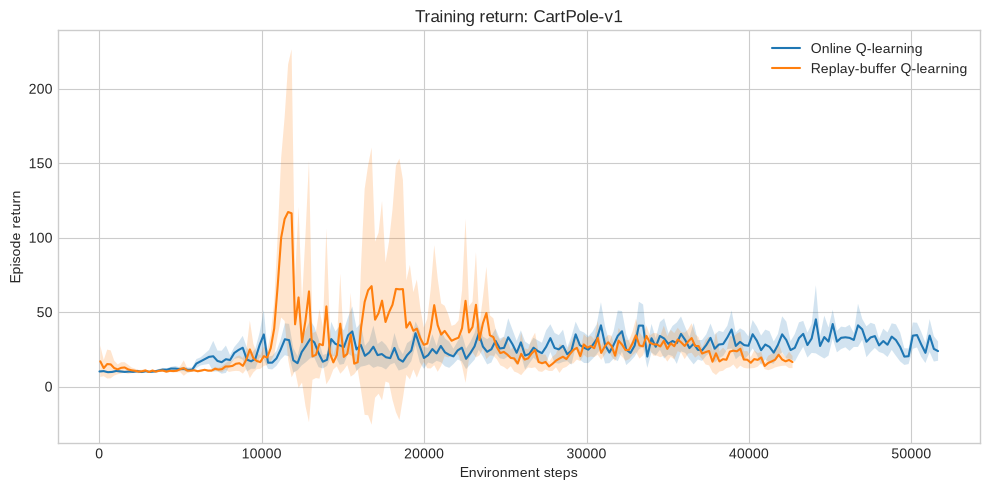

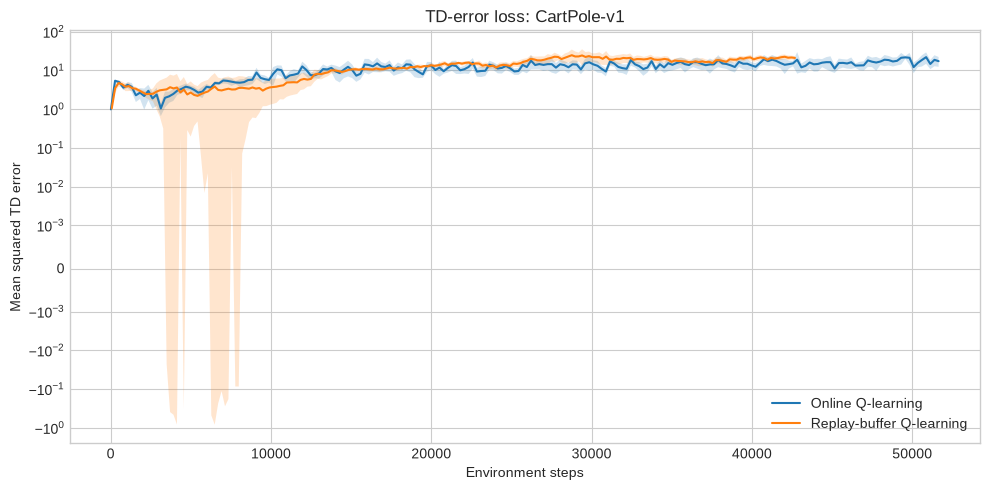

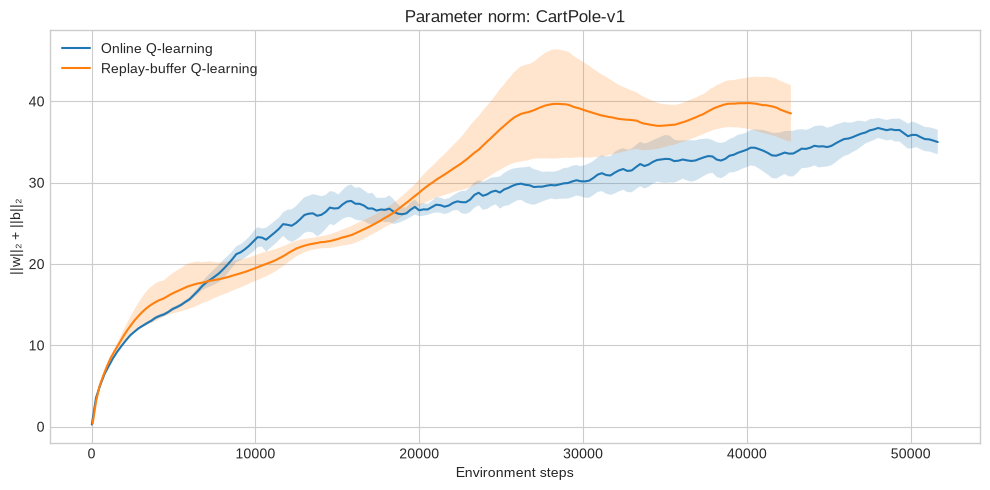

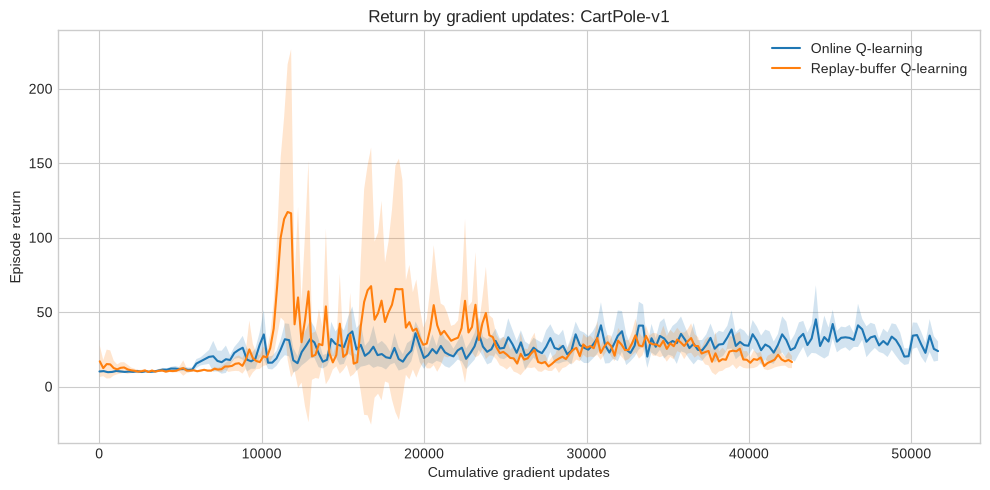

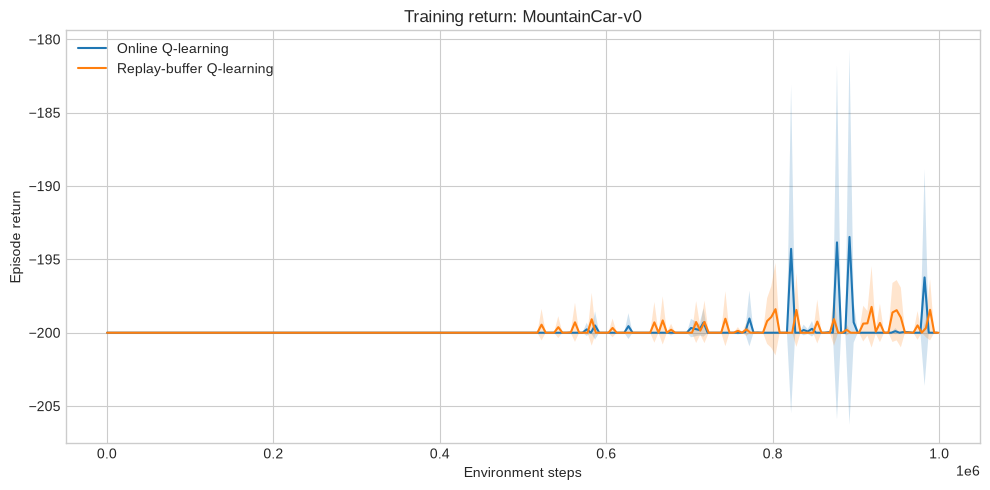

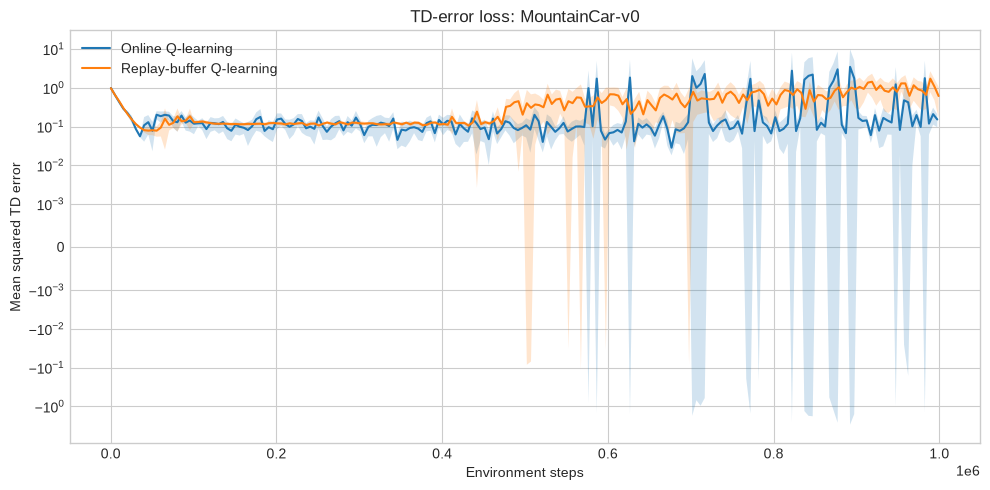

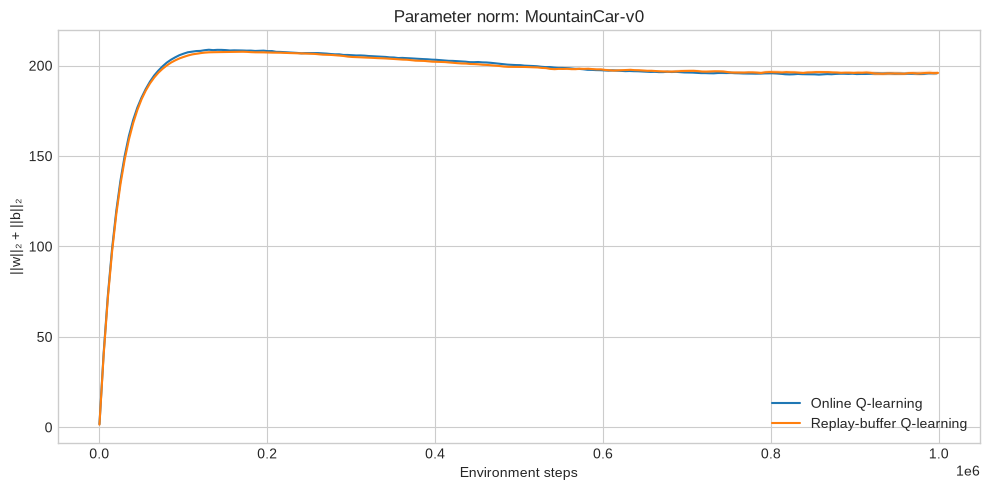

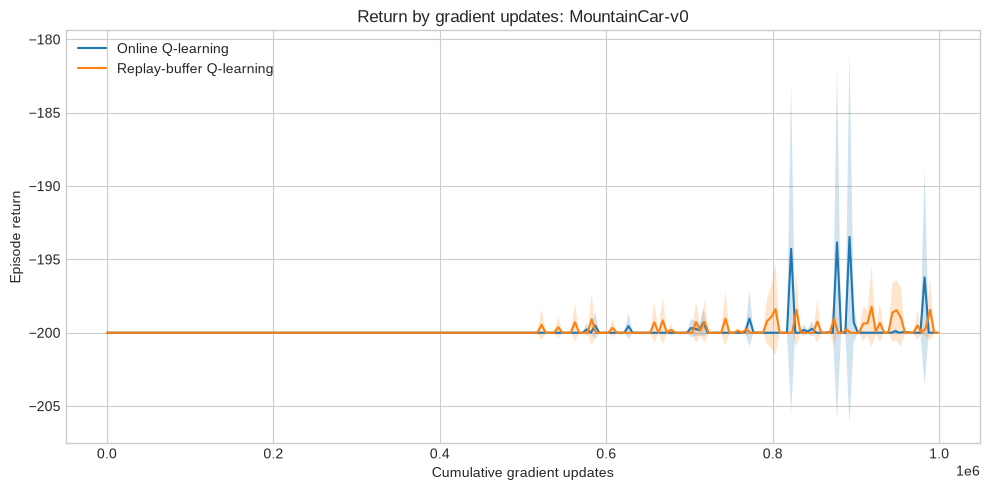

In [7]:
for env_id in ACTIVE_ENV_CONFIGS:
    plot_training_returns(results, env_id)
    plot_td_losses(results, env_id)
    plot_parameter_norms(results, env_id)
    plot_return_by_updates(results, env_id)
    plt.show()

## Reading the Results

The figures support a representation-first interpretation.

- **CartPole:** The replay-buffer agent shows short-lived spikes in return, especially around the middle of training, but the wide confidence band indicates high variability across seeds. Later, online Q-learning is often as good as or better than replay-buffer Q-learning. The return-by-updates plot has essentially the same story, so the apparent spikes are not evidence of a sustained replay advantage. The TD-error curves remain of similar magnitude, while the replay agent develops a larger parameter norm for part of training. More updates and larger weights do not translate into reliably better control.
- **MountainCar:** Both agents remain close to a return of `-200` for almost the entire run, with only occasional small improvements. The return-by-updates plot confirms that the lack of progress is not explained simply by the environment-step budget. The parameter norms rapidly grow to a similar level for both agents, and the TD-error plots become noisy without corresponding improvement in return. Replay changes the update statistics, but neither method discovers a useful policy.

These results do not show that replay buffers are ineffective in general. They show that replay cannot compensate for a mismatch between the task and the representation. With raw state vectors and a linear approximator, the agents have limited ability to represent the nonlinear state-action relationships needed for balancing the pole or building momentum toward the MountainCar goal. The experiment therefore makes a practical point: reward design, state representation, and action representation should be made adequate first; advanced optimization and data-reuse techniques come afterward.

A useful follow-up is to keep the environment, reward, and online update schedule fixed while replacing the linear value function with a neural network. If the network is expressive enough to represent the relevant state-action relationships, ordinary online updates may learn successfully even without replay. That experiment would test the missing ingredient directly: function capacity, rather than another change to the sampling procedure.